# IT2011 — Progress Review I: Individual Contribution
### Encoding Categorical Variables
**IT Number:** IT25103810
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011


## Setup & Loading the Dataset

We load the dataset directly from `sklearn.datasets` (`load_breast_cancer`), which contains the **exact same 569 records / 30 features** as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset referenced in our proposal.

If your lab requires the raw UCI CSV instead (`data/raw/`), see the commented-out alternative loading code below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Encoding Categorical Variables

**Technique:** Label encoding of the target variable.

**Explanation:** ML algorithms require numeric input/output — categorical text labels must be converted to numbers before they can be used to train or evaluate a classifier.

**Justification for this dataset:** All 30 predictor features are already continuous numeric measurements (confirmed in proposal Slide 4), so no input feature needs encoding. The **only** categorical variable in the dataset is the target label `diagnosis` (`M` = Malignant, `B` = Benign), which must be encoded to `0`/`1` before it can be used as the model's `y`.


In [2]:
print("Unique classes before encoding:", df["diagnosis"].unique())

le = LabelEncoder()
df["diagnosis_encoded"] = le.fit_transform(df["diagnosis"])   # B -> 0, M -> 1 (alphabetical)

print("Encoding map:", dict(zip(le.classes_, le.transform(le.classes_))))
df[["diagnosis", "diagnosis_encoded"]].head()

Unique classes before encoding: <StringArray>
['M', 'B']
Length: 2, dtype: str
Encoding map: {'B': np.int64(0), 'M': np.int64(1)}


,diagnosis,diagnosis_encoded
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


/tmp/ipykernel_178/1548775423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="diagnosis", data=df, order=["B", "M"], palette=["#4C9F70", "#D9534F"])


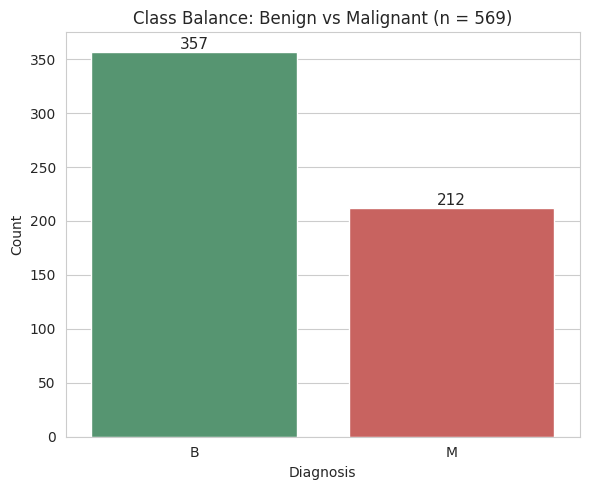

In [3]:
# ---- EDA Visualization: class balance ----
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="diagnosis", data=df, order=["B", "M"], palette=["#4C9F70", "#D9534F"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.title("Class Balance: Benign vs Malignant (n = 569)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** 357 Benign vs 212 Malignant — roughly a 63:37 split. This is a **mild class imbalance**, not severe enough to require SMOTE/undersampling, but enough that we should use **stratified train/test splits** and report **Recall & F1-score** alongside Accuracy later in modelling, so the majority (Benign) class doesn't mask poor performance on Malignant cases — which is clinically the more costly type of error to miss.